In [1]:
import sys, os, re, jax
sys.path.append(os.path.abspath("./../../feedback-grape"))
sys.path.append(os.path.abspath("./../../"))
sys.path.append(os.path.abspath("./../"))

from matplotlib import pyplot as plt
import numpy as np

from plot_helpers import (
    open_from_dir,
    plot_runs,
    plot_runs_1D,
    plot_grid,
    grid_grouped_params,
    select_best_runs,
    extract_time_constants,
    white_outline,
)

Opening files...


100%|██████████| 576/576 [00:00<00:00, 101624.49it/s]


Done.
Chosen as best model parameters: s=1
Opening files...


100%|██████████| 144/144 [00:00<00:00, 116891.77it/s]


Done.
Opening files...


...

Done.
Chosen as best model parameters: s=3
Opening files...


100%|██████████| 144/144 [00:00<00:00, 111107.39it/s]


Done.
Opening files...


100%|██████████| 145/145 [00:00<00:00, 88090.10it/s]

Done.


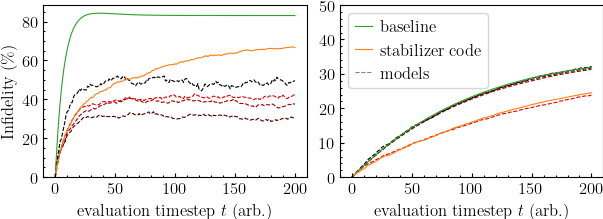

In [ ]:
dir_ = "./01_results"

# gamma values to choose from:
#       0.0001, 0.0001873817422860383, 0.0003511191734215131, 0.0006579332246575682, 0.0012328467394420659, 0.002310129700083158
#       0.004328761281083057, 0.008111308307896872, 0.01519911082952933, 0.02848035868435799, 0.05336699231206307, 0.1
gamma_pairs = [
    (0.05336699231206307, 0.008111308307896872), # here, model excels
    #(0.1, 0.02848035868435799), # here, model excels
    (0.0001, 0.004328761281083057), # here, some models perform exactly as well as stabilizer code, some exactly as bad as baseline
]

max_time = 200

fig, axs = plt.subplots(1, len(gamma_pairs), figsize=(6.1811, 2.5))
axs = axs.flatten()
for i, ((gamma_p, gamma_m), ax) in enumerate(zip(gamma_pairs, axs)):
    exclude = rf"^(?!.*gammap={gamma_p}_gammam={gamma_m}_).*$"

    fidelities_mat, params_grouped, params_each = open_from_dir(dir_ + "/eval", exclude=exclude)
    fidelities_mat = fidelities_mat[:, : max_time + 1]
    fidelities_best_mat, params_grouped_best, params_each_best = select_best_runs(fidelities_mat, params_each)

    print(f"Chosen as best model parameters: s={params_grouped_best['s'][0]}")
    fidelities_mat_stab, params_grouped_stab, params_each_stab = open_from_dir(dir_ + "/custom/Stabilizer code", exclude=exclude)
    fidelities_mat_stab = fidelities_mat_stab[:, : max_time + 1]
    fidelities_mat_base, params_grouped_base, params_each_base = open_from_dir(dir_ + "/baseline", exclude=exclude)
    fidelities_mat_base = fidelities_mat_base[:, : max_time + 1]


    ax.set_xlabel("$\\textrm{evaluation timestep }t\\textrm{ (arb.)}$")

    ax.plot((1 - fidelities_mat_base[0])*100, label="$\\textrm{baseline}$", color="C2", zorder=1)
    ax.plot((1 - fidelities_mat_stab[0])*100, label="$\\textrm{stabilizer code}$", color="C1", zorder=1)

    for fidelities, p in zip(fidelities_mat, params_each):
        red = 0. + 0.9 * (p['s'] / max(params_grouped['s']))
        ax.plot((1 - fidelities)*100, color = (red, 0, 0), zorder=0, ls = '--')

    ax.set_ylim(ymin=0)
    plt.tight_layout()

axs[0].set_ylabel("$\\textrm{Infidelity (\\%)}$")
axs[1].set_ylim(0,50)
axs[1].plot([], [], color="grey", label="$\\textrm{models}$", ls='--')
axs[1].legend(loc="upper left", ncol=1)

plt.subplots_adjust(wspace=0.125, hspace=0)
fig.savefig(f"{dir_}/specific_system_gamma_p={gamma_p}_gamma_m={gamma_m}.svg")